# Phase 1: Environment Setup & Data Acquisition
* **Framework:** PyTorch
* **Audio Library:** Librosa
* **Dataset:** ASVspoof 2019 Logical Access (LA)

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

# Standard Library & Data Handling
import random
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# Audio Processing & Visualization
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch Core & Neural Networks
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
from torchvision.models import resnet18

# Evaluation Metrics
from sklearn.metrics import roc_curve, auc

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Libraries Loaded & Drive Mounted. Random Seed locked to {SEED}.")

Mounted at /content/drive
Libraries Loaded & Drive Mounted. Random Seed locked to 42.


In [2]:
# Establish Train Paths
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/(ELEC3) Audio Deepfake Detection /Dataset/LA"
TRAIN_PROTOCOL_PATH = os.path.join(BASE_DIR, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")
FLAC_DIR = os.path.join(BASE_DIR, "flac/")
OUT_DIR_1D = os.path.join(BASE_DIR, "features_1d/")
OUT_DIR_2D = os.path.join(BASE_DIR, "features_2d/")

# Establish Evaluation Paths
EVAL_PROTOCOL_PATH = os.path.join(BASE_DIR, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt")
EVAL_FLAC_DIR = os.path.join(BASE_DIR, "ASVspoof2019_LA_eval/flac")
EVAL_OUT_DIR_1D = os.path.join(BASE_DIR, "eval_features_1d/")
EVAL_OUT_DIR_2D = os.path.join(BASE_DIR, "eval_features_2d/")

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment Ready. Compute Device: {device}")

Environment Ready. Compute Device: cuda


# Phase 2: Data Preprocessing
1. **Standardization:** Load audio at 16kHz and pad/truncate to exactly 4 seconds (64,000 samples).
2. **1D Transformation:** Save the raw time-series amplitude arrays natively.
3. **2D Transformation:** Convert the standardized audio into 128-band Mel-Spectrograms on a decibel (log) scale.

In [3]:
os.makedirs(OUT_DIR_1D, exist_ok=True)
os.makedirs(OUT_DIR_2D, exist_ok=True)

SAMPLE_RATE = 16000
TARGET_SAMPLES = SAMPLE_RATE * 4

def pad_or_truncate(audio_array, target_length):
    current_length = len(audio_array)
    if current_length > target_length:
        return audio_array[:target_length]
    elif current_length < target_length:
        return np.pad(audio_array, (0, target_length - current_length), mode='constant')
    return audio_array

columns = ['Speaker_ID', 'File_Name', 'System_ID', 'Attack_ID', 'Label']
full_df = pd.read_csv(TRAIN_PROTOCOL_PATH, sep=' ', names=columns)

# Enforce the 500/500 subset rule
df_real = full_df[full_df['Label'] == 'bonafide'].sample(n=500, random_state=42)
df_fake = full_df[full_df['Label'] == 'spoof'].sample(n=500, random_state=42)
subset_df = pd.concat([df_real, df_fake]).reset_index(drop=True)

print(f"Starting Preprocessing for {len(subset_df)} files.")

for index, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Extracting Audio Features"):
    file_name = row['File_Name']
    flac_path = os.path.join(FLAC_DIR, f"{file_name}.flac")

    # Define the output paths
    out_path_1d = os.path.join(OUT_DIR_1D, f"{file_name}.npy")
    out_path_2d = os.path.join(OUT_DIR_2D, f"{file_name}.npy")

    # If both files already exist in Drive, skip
    if os.path.exists(out_path_1d) and os.path.exists(out_path_2d):
        continue

    if not os.path.exists(flac_path):
        continue

    try:
        y, _ = librosa.load(flac_path, sr=SAMPLE_RATE)
        y_standardized = pad_or_truncate(y, TARGET_SAMPLES).astype(np.float32)

        # Save 1D
        np.save(out_path_1d, y_standardized)

        # Save 2D
        S = librosa.feature.melspectrogram(y=y_standardized, sr=SAMPLE_RATE, n_fft=1024, hop_length=256, n_mels=128)
        S_db = librosa.power_to_db(S, ref=np.max).astype(np.float32)
        np.save(out_path_2d, S_db)

    except Exception as e:
        pass

print("Preprocessing Complete.")

Starting Preprocessing for 1000 files.


Extracting Audio Features:   0%|          | 0/1000 [00:00<?, ?it/s]

Preprocessing Complete.


# Phase 3: PyTorch DataLoaders & Augmentation
**Objective:** Build custom PyTorch classes to batch the `.npy` files efficiently into the GPU.
* **SpecAugment (2D):** Applied exclusively to the 2D dataloader to randomly mask time steps and frequency bands, preventing model overfitting.
* **Gaussian Noise (1D):** Applied exclusively to the 1D dataloader to randomly inject signal static into the raw waveform, preventing model overfitting.

In [4]:
# 1D RawWaveform Augmenter
class AdditiveGaussianNoise(nn.Module):
    def __init__(self, noise_factor=0.005, apply_prob=0.5):
        super(AdditiveGaussianNoise, self).__init__()
        self.noise_factor = noise_factor
        self.apply_prob = apply_prob

    def forward(self, waveform):
        if random.random() < self.apply_prob:
            noise = torch.randn_like(waveform) * self.noise_factor
            waveform = waveform + noise
        return waveform

# Dataset Class to handle 1D transforms
class ASVspoofDatasetSubset(Dataset):
    def __init__(self, dataframe, feature_dir, mode='2d', transform_2d=None, transform_1d=None):
        self.dataframe = dataframe
        self.feature_dir = feature_dir
        self.mode = mode
        self.transform_2d = transform_2d
        self.transform_1d = transform_1d

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        file_name = self.dataframe.iloc[idx]['File_Name']
        label_str = self.dataframe.iloc[idx]['Label']
        label = 1.0 if label_str == 'spoof' else 0.0

        filepath = os.path.join(self.feature_dir, f"{file_name}.npy")
        data = np.load(filepath)

        if self.mode == '2d':
            tensor_data = torch.tensor(data).unsqueeze(0)
            if self.transform_2d:
                tensor_data = self.transform_2d(tensor_data)
        elif self.mode == '1d':
            tensor_data = torch.tensor(data).unsqueeze(0)
            if self.transform_1d:
                tensor_data = self.transform_1d(tensor_data)

        return tensor_data, torch.tensor(label, dtype=torch.float32)

# 2D Augmenter (SpecAugment)
spec_augmenter = nn.Sequential(
    T.FrequencyMasking(freq_mask_param=15),
    T.TimeMasking(time_mask_param=30)
)

# 1D Augmenter (Gaussian Noise)
raw_augmenter = AdditiveGaussianNoise(noise_factor=0.005, apply_prob=0.5)

# Build DataLoaders
dataset_2d = ASVspoofDatasetSubset(subset_df, OUT_DIR_2D, mode='2d', transform_2d=spec_augmenter)
dataloader_2d = DataLoader(dataset_2d, batch_size=32, shuffle=True)

dataset_1d = ASVspoofDatasetSubset(subset_df, OUT_DIR_1D, mode='1d', transform_1d=raw_augmenter)
dataloader_1d = DataLoader(dataset_1d, batch_size=32, shuffle=True)

print("DataLoaders ready. 1D and 2D Augmentations Active.")

DataLoaders ready. 1D and 2D Augmentations Active.


# Phase 4: CNN Architecture Design
**Objective:** Initialize the models.
1. **2D Model:** ResNet-18 modified to accept 1-channel grayscale spectrograms.
2. **1D Model:** RawNet2 designed to scan raw sequences.

In [5]:
# 1. The 2D Baseline: ResNet-18
class DeepfakeResNet2D(nn.Module):
    def __init__(self):
        super(DeepfakeResNet2D, self).__init__()
        self.model = resnet18(weights=None)
        original_conv1 = self.model.conv1
        self.model.conv1 = nn.Conv2d(1, original_conv1.out_channels, kernel_size=original_conv1.kernel_size, stride=original_conv1.stride, padding=original_conv1.padding, bias=False)
        self.model.fc = nn.Sequential(
            nn.Linear(self.model.fc.in_features, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

# 2. The 1D Baseline: RawNet2
class FMS(nn.Module):
    """Feature Map Scaling (FMS) - Acts as a channel-wise attention mechanism"""
    def __init__(self, dim):
        super(FMS, self).__init__()
        self.fc = nn.Linear(dim, dim)
        self.sig = nn.Sigmoid()

    def forward(self, x):
        y = F.adaptive_avg_pool1d(x, 1).view(x.size(0), -1)
        y = self.sig(self.fc(y)).view(x.size(0), x.size(1), 1)
        return x * y

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.fms = FMS(out_channels)
        self.mp = nn.MaxPool1d(3)

        # Match dimensions if they differ
        self.downsample = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=1),
            nn.BatchNorm1d(out_channels)
        ) if in_channels != out_channels else None

    def forward(self, x):
        identity = x
        out = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.3)
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.mp(self.fms(out))
        return out

class DeepfakeRawNet2(nn.Module):
    def __init__(self):
        super(DeepfakeRawNet2, self).__init__()
        # Front-end feature extraction directly from the raw waveform
        self.conv_front = nn.Sequential(
            nn.Conv1d(1, 20, kernel_size=80, stride=4),
            nn.BatchNorm1d(20),
            nn.LeakyReLU(0.3)
        )

        # Residual Blocks with FMS
        self.res1 = ResidualBlock1D(20, 32)
        self.res2 = ResidualBlock1D(32, 64)

        # GRU to analyze the temporal sequence of the extracted features
        self.gru = nn.GRU(input_size=64, hidden_size=64, num_layers=1, batch_first=True)

        # Final classification
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.LeakyReLU(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_front(x)
        x = self.res1(x)
        x = self.res2(x)

        # Prepare for GRU: swap axes from [Batch, Channels, Time] to [Batch, Time, Channels]
        x = x.transpose(1, 2)
        x, _ = self.gru(x)

        # Take the output of the final time step
        x = x[:, -1, :]
        return self.fc(x)

# Initialize Models
model_2d = DeepfakeResNet2D()
model_1d = DeepfakeRawNet2()

print("ResNet-18 and RawNet2 Architectures Initialized.")

ResNet-18 and RawNet2 Architectures Initialized.


# Phase 5: Training Loop

*   Train the models using Binary Cross-Entropy (BCE) Loss and the Adam Optimizer to map the acoustic features to the binary labels.

In [6]:
def train_model(model, dataloader, model_name="Model", num_epochs=5, learning_rate=0.001):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"\nTraining: {model_name}")
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for features, labels in loop:
            features, labels = features.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * features.size(0)
            predictions = (outputs >= 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        print(f"Epoch [{epoch+1}/{num_epochs}] -> Loss: {running_loss/total:.4f} | Accuracy: {(correct/total)*100:.2f}%")
    return model

trained_resnet = train_model(model_2d, dataloader_2d, "2D ResNet-18", num_epochs=100)
trained_rawnet = train_model(model_1d, dataloader_1d, "RawNet2", num_epochs=100)

torch.save(trained_resnet.state_dict(), '/content/resnet18_baseline.pth')
torch.save(trained_rawnet.state_dict(), '/content/rawnet2_baseline.pth')
print("Baseline Models Saved Successfully.")


Training: 2D ResNet-18


Epoch 1/100:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch [1/100] -> Loss: 0.6006 | Accuracy: 71.00%


Epoch 2/100:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch [2/100] -> Loss: 0.3617 | Accuracy: 86.10%


...

Epoch [98/100] -> Loss: 0.0848 | Accuracy: 96.70%


Epoch 99/100:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch [99/100] -> Loss: 0.0599 | Accuracy: 97.80%


Epoch 100/100:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch [100/100] -> Loss: 0.1017 | Accuracy: 96.00%
Baseline Models Saved Successfully.


# Phase 6: Training Performance (Sanity Check & Overfitting Baseline)

*   Objective: Evaluate the models on the data they just trained on. This is not our real-world score; rather, it establishes a baseline to verify the architectures are successfully learning and allows us to measure the degree of overfitting when compared to the unseen evaluation data in Phase 7.




Evaluating 2D ResNet-18:   0%|          | 0/32 [00:00<?, ?it/s]


2D ResNet-18 | EER: 0.20% | AUC: 1.0000


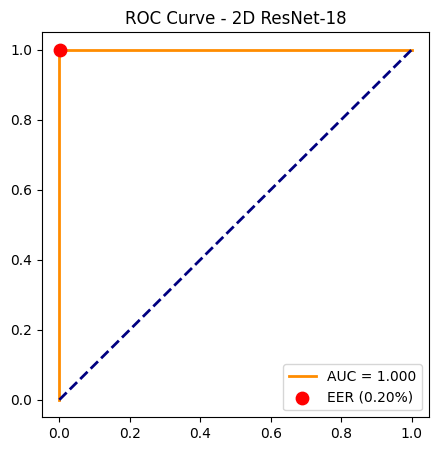

Evaluating RawNet2:   0%|          | 0/32 [00:00<?, ?it/s]


RawNet2 | EER: 2.00% | AUC: 0.9990


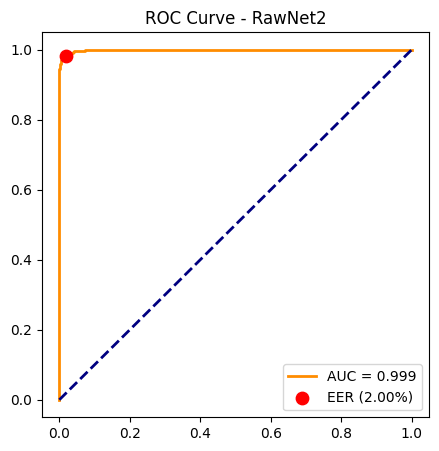

np.float64(2.0)

In [7]:
def evaluate_model(model, dataloader, model_name="Model"):
    model = model.to(device)
    model.eval()
    y_true, y_scores = [], []

    with torch.no_grad():
        for features, labels in tqdm(dataloader, desc=f"Evaluating {model_name}"):
            features, labels = features.to(device), labels.to(device)
            outputs = model(features).squeeze()
            y_scores.extend(outputs.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    y_true, y_scores = np.array(y_true), np.array(y_scores)

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer_index = np.argmin(np.absolute(fpr - fnr))
    eer = fpr[eer_index] * 100
    roc_auc = auc(fpr, tpr)

    print(f"\n{model_name} | EER: {eer:.2f}% | AUC: {roc_auc:.4f}")

    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(fpr[eer_index], tpr[eer_index], color='red', s=80, label=f'EER ({eer:.2f}%)', zorder=5)
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

    return eer

evaluate_model(trained_resnet, dataloader_2d, "2D ResNet-18")
evaluate_model(trained_rawnet, dataloader_1d, "RawNet2")



# Phase 7: Real-World Evaluation (Unseen Data)
**Objective:** Test the trained ResNet-18 and RawNet2 models against a completely unseen subset of the ASVspoof2019 Evaluation dataset. This phase includes its own independent preprocessing pipeline with smart-bypass and dataframe auditing to ensure data integrity.

Extracting Eval Features.:   0%|          | 0/1000 [00:00<?, ?it/s]


Data Audit Complete. Ready to test 1000 unseen files.

TRUE EVALUATION: Baseline 2D ResNet-18


Evaluating 2D ResNet-18 (Unseen Data):   0%|          | 0/32 [00:00<?, ?it/s]


2D ResNet-18 (Unseen Data) | EER: 11.20% | AUC: 0.9582


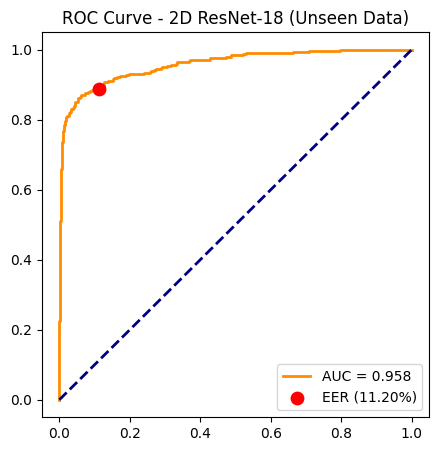


TRUE EVALUATION: Baseline 1D RawNet2


Evaluating RawNet2 (Unseen Data):   0%|          | 0/32 [00:00<?, ?it/s]


RawNet2 (Unseen Data) | EER: 26.80% | AUC: 0.8032


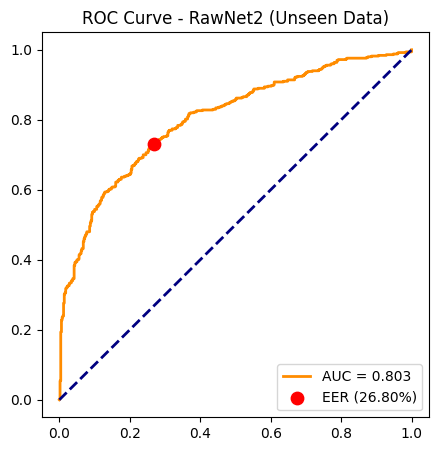

In [8]:
os.makedirs(EVAL_OUT_DIR_1D, exist_ok=True)
os.makedirs(EVAL_OUT_DIR_2D, exist_ok=True)

# Define the Unseen Evaluation Subset (1000 Files)
columns = ['Speaker_ID', 'File_Name', 'System_ID', 'Attack_ID', 'Label']
eval_df = pd.read_csv(EVAL_PROTOCOL_PATH, sep=' ', names=columns)

df_eval_real = eval_df[eval_df['Label'] == 'bonafide'].sample(n=500, random_state=42)
df_eval_fake = eval_df[eval_df['Label'] == 'spoof'].sample(n=500, random_state=42)
subset_eval_df = pd.concat([df_eval_real, df_eval_fake]).reset_index(drop=True)

# Preprocessing
for index, row in tqdm(subset_eval_df.iterrows(), total=len(subset_eval_df), desc="Extracting Eval Features."):
    file_name = row['File_Name']
    flac_path = os.path.join(EVAL_FLAC_DIR, f"{file_name}.flac")
    out_path_1d = os.path.join(EVAL_OUT_DIR_1D, f"{file_name}.npy")
    out_path_2d = os.path.join(EVAL_OUT_DIR_2D, f"{file_name}.npy")

    # Skip if both arrays already exist
    if os.path.exists(out_path_1d) and os.path.exists(out_path_2d):
        continue

    if not os.path.exists(flac_path):
        print(f"Missing raw audio: {flac_path}")
        continue

    try:
        y, _ = librosa.load(flac_path, sr=SAMPLE_RATE)
        y_standardized = pad_or_truncate(y, TARGET_SAMPLES).astype(np.float32)

        np.save(out_path_1d, y_standardized) # Save 1D

        S = librosa.feature.melspectrogram(y=y_standardized, sr=SAMPLE_RATE, n_fft=1024, hop_length=256, n_mels=128)
        S_db = librosa.power_to_db(S, ref=np.max).astype(np.float32)
        np.save(out_path_2d, S_db) # Save 2D
    except Exception as e:
        print(f"Error processing {file_name}: {e}")

# Audit Data and Build Loaders
valid_eval_rows = []
for index, row in subset_eval_df.iterrows():
    out_path_2d = os.path.join(EVAL_OUT_DIR_2D, f"{row['File_Name']}.npy")
    out_path_1d = os.path.join(EVAL_OUT_DIR_1D, f"{row['File_Name']}.npy")

    if os.path.exists(out_path_2d) and os.path.exists(out_path_1d):
        valid_eval_rows.append(row)

clean_eval_df = pd.DataFrame(valid_eval_rows)
print(f"\nData Audit Complete. Ready to test {len(clean_eval_df)} unseen files.")

# Transform_2d and Transform_1d
dataset_eval_2d = ASVspoofDatasetSubset(clean_eval_df, EVAL_OUT_DIR_2D, mode='2d', transform_2d=None)
dataloader_eval_2d = DataLoader(dataset_eval_2d, batch_size=32, shuffle=False)

dataset_eval_1d = ASVspoofDatasetSubset(clean_eval_df, EVAL_OUT_DIR_1D, mode='1d', transform_1d=None)
dataloader_eval_1d = DataLoader(dataset_eval_1d, batch_size=32, shuffle=False)

# Execute True Evaluation
print("\nTRUE EVALUATION: Baseline 2D ResNet-18")
eer_resnet_true = evaluate_model(trained_resnet, dataloader_eval_2d, "2D ResNet-18 (Unseen Data)")

print("\nTRUE EVALUATION: Baseline 1D RawNet2")
eer_rawnet_true = evaluate_model(trained_rawnet, dataloader_eval_1d, "RawNet2 (Unseen Data)")

# Phase 8: Experiment 3 (Architectural Ablation)
**Objective:** Tweak the internal architecture of the baseline models to test for improvements in the unseen Evaluation Equal Error Rate (EER).
* **2D ResNet-18 (Regularization):** Added a 50% Dropout layer to the classification head to prevent the model from overfitting to specific pixels.
* **1D RawNet2 (Temporal Expansion):** Doubled the GRU hidden memory (64 to 128) to allow the network to track longer phase anomalies.

Architectural Ablation
Tweaked Architectures Initialized.

Training Tweaked 2D ResNet-18

Training: Tweaked 2D ResNet


Epoch 1/100:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch [1/100] -> Loss: 0.5834 | Accuracy: 69.80%


Epoch 2/100:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch [2/100] -> Loss: 0.3439 | Accuracy: 87.30%


...

Epoch [99/100] -> Loss: 0.0478 | Accuracy: 98.20%


Epoch 100/100:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch [100/100] -> Loss: 0.0609 | Accuracy: 98.00%

TRUE EVALUATION: Tweaked 2D ResNet-18


Evaluating Tweaked 2D ResNet (Unseen Data):   0%|          | 0/32 [00:00<?, ?it/s]


Tweaked 2D ResNet (Unseen Data) | EER: 11.60% | AUC: 0.9513


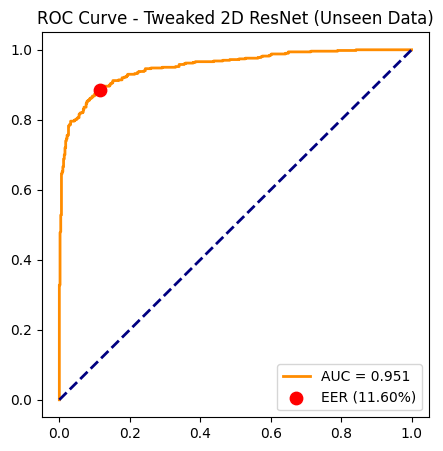


TRUE EVALUATION: Tweaked 1D RawNet2


Evaluating Tweaked 1D RawNet (Unseen Data):   0%|          | 0/32 [00:00<?, ?it/s]


Tweaked 1D RawNet (Unseen Data) | EER: 23.20% | AUC: 0.8398


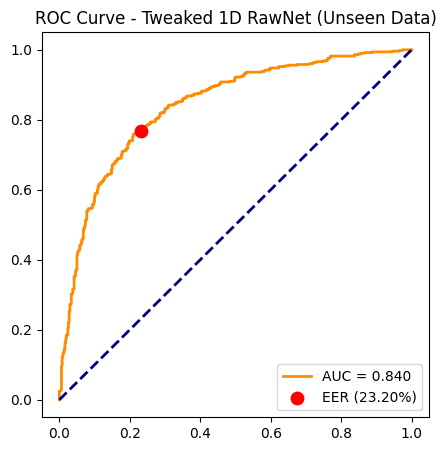

Tweaked Models Saved Successfully.


In [9]:
print("Architectural Ablation")

class DeepfakeResNet2D_Tweaked(nn.Module):
    def __init__(self):
        super(DeepfakeResNet2D_Tweaked, self).__init__()
        self.model = resnet18(weights=None)
        original_conv1 = self.model.conv1
        self.model.conv1 = nn.Conv2d(1, original_conv1.out_channels, kernel_size=original_conv1.kernel_size, stride=original_conv1.stride, padding=original_conv1.padding, bias=False)

        # Added 50% Dropout
        self.model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(self.model.fc.in_features, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

class DeepfakeRawNet2_Tweaked(nn.Module):
    def __init__(self):
        super(DeepfakeRawNet2_Tweaked, self).__init__()
        self.conv_front = nn.Sequential(
            nn.Conv1d(1, 20, kernel_size=80, stride=4),
            nn.BatchNorm1d(20),
            nn.LeakyReLU(0.3)
        )
        self.res1 = ResidualBlock1D(20, 32)
        self.res2 = ResidualBlock1D(32, 64)

        # Doubled GRU hidden capacity from 64 to 128
        self.gru = nn.GRU(input_size=64, hidden_size=128, num_layers=1, batch_first=True)

        self.fc = nn.Sequential(
            nn.Linear(128, 64), # Must match the new GRU output
            nn.LeakyReLU(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_front(x)
        x = self.res1(x)
        x = self.res2(x)
        x = x.transpose(1, 2)
        x, _ = self.gru(x)
        x = x[:, -1, :]
        return self.fc(x)

# Initialize the new tweaked models
model_2d_tweaked = DeepfakeResNet2D_Tweaked()
model_1d_tweaked = DeepfakeRawNet2_Tweaked()

print("Tweaked Architectures Initialized.")

# Train the Tweaked Models (Using Phase 3 Training DataLoaders)
print("\nTraining Tweaked 2D ResNet-18")
trained_resnet_tweaked = train_model(model_2d_tweaked, dataloader_2d, "Tweaked 2D ResNet", num_epochs=100)

print("\nTraining Tweaked 1D RawNet2")
trained_rawnet_tweaked = train_model(model_1d_tweaked, dataloader_1d, "Tweaked 1D RawNet", num_epochs=100)

# True Evaluation (Using Phase 7 Unseen DataLoaders)
print("\nTRUE EVALUATION: Tweaked 2D ResNet-18")
eer_resnet_tweaked = evaluate_model(trained_resnet_tweaked, dataloader_eval_2d, "Tweaked 2D ResNet (Unseen Data)")

print("\nTRUE EVALUATION: Tweaked 1D RawNet2")
eer_rawnet_tweaked = evaluate_model(trained_rawnet_tweaked, dataloader_eval_1d, "Tweaked 1D RawNet (Unseen Data)")

torch.save(trained_resnet_tweaked.state_dict(), '/content/resnet18_tweaked.pth')
torch.save(trained_rawnet_tweaked.state_dict(), '/content/rawnet2_tweaked.pth')
print("Tweaked Models Saved Successfully.")

# Phase 9: Final Results & Analysis
**Objective:** Aggregate, visualize, and export the final Evaluation metrics across all baseline and experimental models.

### Scientific Evaluation Criteria
The primary metric for the ASVspoof 2019 dataset is the **Equal Error Rate (EER)**, which represents the operating point where the False Acceptance Rate (FAR) and False Rejection Rate (FRR) are perfectly balanced. A **lower** EER indicates a more accurate and robust deepfake detection model.

### Summary of Experiments
* **Baseline Models:** Evaluated the standard architectures of 2D ResNet-18 and 1D RawNet2.
* **Architectural Ablation (Tweaks):** Evaluated the impact of a 0.5 Dropout regularization on the ResNet-18 classification head, and a 128-dimensional GRU expansion on the RawNet2 temporal memory.


Final Performance Table:


,Model Architecture,Input Feature,Evaluation EER (%)
0,2D ResNet-18 (Baseline),Mel-Spectrogram,11.2
1,2D ResNet-18 (Tweaked - 50% Dropout),Mel-Spectrogram,11.6
2,1D RawNet2 (Tweaked - 128 GRU),Raw Waveform,23.2
3,1D RawNet2 (Baseline),Raw Waveform,26.8



Graph saved to: /content/drive/MyDrive/Colab Notebooks/datasets/LA/Final_EER_Results_Chart.png
Table saved to: /content/drive/MyDrive/Colab Notebooks/datasets/LA/Final_EER_Results_Table.csv


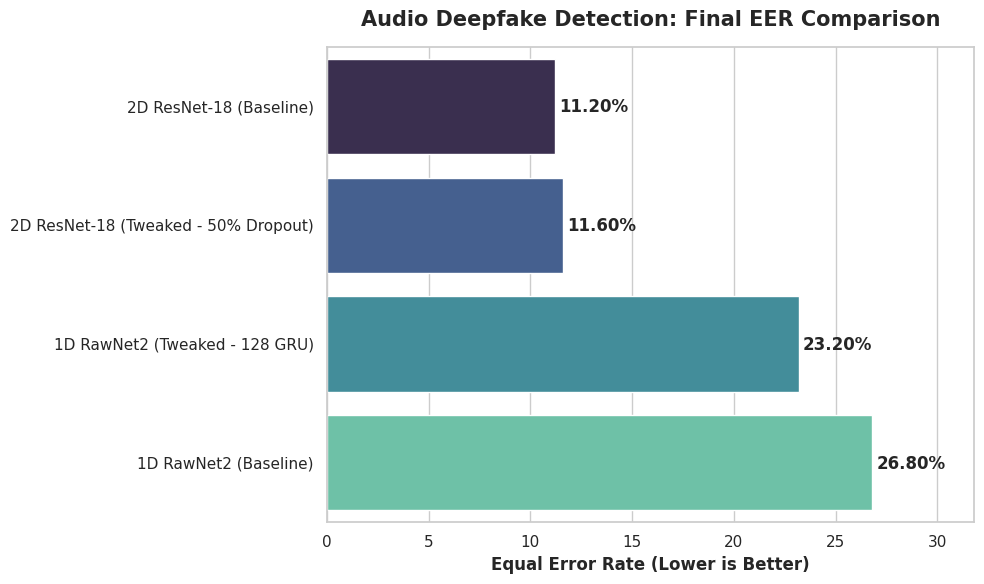

In [10]:
# Summary DataFrame
results_data = {
    "Model Architecture": [
        "2D ResNet-18 (Baseline)",
        "1D RawNet2 (Baseline)",
        "2D ResNet-18 (Tweaked - 50% Dropout)",
        "1D RawNet2 (Tweaked - 128 GRU)"
    ],
    "Input Feature": ["Mel-Spectrogram", "Raw Waveform", "Mel-Spectrogram", "Raw Waveform"],
    "Evaluation EER (%)": [
        eer_resnet_true,
        eer_rawnet_true,
        eer_resnet_tweaked,
        eer_rawnet_tweaked
    ]
}

df_results = pd.DataFrame(results_data)
df_results = df_results.sort_values(by="Evaluation EER (%)", ascending=True).reset_index(drop=True)

print("\nFinal Performance Table:")
display(df_results)

# Comparison with a Bar Chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    x="Evaluation EER (%)",
    y="Model Architecture",
    data=df_results,
    hue="Model Architecture",
    palette="mako",
    legend=False
)

# Add the exact percentage text to the end of each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.2, p.get_y() + p.get_height()/2. + 0.05, f'{width:.2f}%', ha="left", fontweight='bold')

plt.title("Audio Deepfake Detection: Final EER Comparison", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Equal Error Rate (Lower is Better)", fontsize=12, fontweight='bold')
plt.ylabel("")
plt.xlim(0, max(df_results["Evaluation EER (%)"]) + 5)
plt.tight_layout()

# 3. Export Artifacts for the Final Paper
# Define BASE_DIR if it's not currently loaded in this cell's memory
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/datasets/LA'

graph_path = os.path.join(BASE_DIR, 'Final_EER_Results_Chart.png')
plt.savefig(graph_path, dpi=300, bbox_inches='tight')

csv_path = os.path.join(BASE_DIR, 'Final_EER_Results_Table.csv')
df_results.to_csv(csv_path, index=False)

print(f"\nGraph saved to: {graph_path}")
print(f"Table saved to: {csv_path}")
plt.show()

# Debug


In [11]:
import os

OUT_DIR_1D = os.path.join(BASE_DIR, "features_1d/")
OUT_DIR_2D = os.path.join(BASE_DIR, "features_2d/")

def clean_corrupted_files(directory):
    print(f"Scanning {directory} for corrupted files")
    bad_files = 0
    if os.path.exists(directory):
        for filename in os.listdir(directory):
            if filename.endswith(".npy"):
                filepath = os.path.join(directory, filename)
                # Check if the file is empty or impossibly small
                if os.path.getsize(filepath) < 100:
                    print(f"Deleting corrupted file: {filename}")
                    os.remove(filepath)
                    bad_files += 1
    print(f"Removed {bad_files} corrupted files.\n")

clean_corrupted_files(OUT_DIR_1D)
clean_corrupted_files(OUT_DIR_2D)

Scanning /content/drive/MyDrive/Colab Notebooks/datasets/LA/features_1d/ for corrupted files
Removed 0 corrupted files.

Scanning /content/drive/MyDrive/Colab Notebooks/datasets/LA/features_2d/ for corrupted files
Removed 0 corrupted files.

